In [15]:
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [16]:
from pathlib import Path
import json

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_json(path, payload):
    ensure_dir(Path(path).parent)
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

In [20]:
import pandas as pd

def load_data():
    data = {
        "text": [
            "Congratulations! You have won a free iPhone. Claim now!",
            "Urgent! Your account has been compromised, reset password immediately",
            "Win $1000 cash prize by entering this competition",
            "Limited time offer: Buy 1 get 1 free",
            "Hey, are we still meeting tomorrow for lunch?",
            "Please find the agenda for tomorrow's meeting attached",
            "Can you review this report by today?",
            "Lunch at 1 pm today?",
            "Exclusive deal: Get 50% off your next purchase",
            "You have been selected for a special bonus",
            "Reminder: Your electricity bill is due tomorrow",
            "Team, please submit your project updates by EOD",
            "Win big money now! Click the link",
            "You have won a free ticket to the concert",
            "Can you send me the slides from the last meeting?",
            "Important: Update your contact information immediately",
            "Limited seats available, register now!",
            "This is not spam, just checking in",
            "Your package has been shipped and will arrive tomorrow",
            "Click here to claim your reward points",
            "Are we still on for the client call?",
            "Get a free trial of our premium service today",
            "Urgent: Your subscription is about to expire",
            "Can you approve this request?",
            "Congratulations, you are our lucky winner!",
            "Happy Birthday! Enjoy your special gift",
            "Please review the attached document and respond",
            "Win amazing prizes with our survey",
            "Your order has been confirmed and will ship soon",
            "Reminder: Team meeting at 10 am",
            "Exclusive invitation to our webinar",
            "This is a friendly reminder for your appointment",
            "Limited offer: Claim your free voucher now",
            "Can you send the updated spreadsheet?",
            "You have received a secure message",
            "Don't miss out on this chance to win big",
            "Thank you for your purchase",
            "Your invoice is attached for your reference",
            "Congratulations! You’ve been selected for a gift card",
            "Team, let's finalize the slides before 5 pm",
            "Claim your reward before it expires",
            "Are we meeting tomorrow?",
            "Free entry in our contest: Win exciting prizes",
            "Your subscription has been renewed successfully",
            "Important notice: Password change required",
            "Can you join the Zoom call at 3 pm?",
            "Get free coupons by signing up today",
            "Your bank account has a new alert",
            "This email is regarding the project update",
            "Win cash prizes instantly by clicking here",
            
        ],
        "label": [
            1,1,1,1,0,0,0,0,1,1,
            0,0,1,1,0,1,1,0,0,1,
            0,1,1,0,1,0,1,0,0,1,
            1,0,1,0,1,0,1,0,1,0,
            0,1,0,1,0,1,1,0,1,0  # Exactly 50 labels
        ]
    }

    # Safety check
    assert len(data["text"]) == len(data["label"]), f"Text length {len(data['text'])} != Label length {len(data['label'])}"

    return pd.DataFrame(data)

# Create DataFrame
df = load_data()
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50, 2)


,text,label
0,Congratulations! You have won a free iPhone. C...,1
1,"Urgent! Your account has been compromised, res...",1
2,Win $1000 cash prize by entering this competition,1
3,Limited time offer: Buy 1 get 1 free,1
4,"Hey, are we still meeting tomorrow for lunch?",0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40
Test size: 10


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Create TF-IDF + Logistic Regression pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=3000
    )),
    ("model", LogisticRegression(max_iter=1000))
])

# Train pipeline
pipeline.fit(X_train, y_train)
print("Pipeline trained successfully!")

Pipeline trained successfully!


In [23]:
from sklearn.metrics import f1_score

# Predict on test set
preds = pipeline.predict(X_test)

# Calculate F1 score
f1 = f1_score(y_test, preds)
print("F1 Score on test set:", f1)

F1 Score on test set: 0.6153846153846154


In [24]:
import joblib
import os
import json
from pathlib import Path

# Helper function
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_json(path, payload):
    ensure_dir(Path(path).parent)
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

# Save pipeline
ensure_dir("models")
joblib.dump(pipeline, "models/spam_pipeline.joblib")

# Save metrics
save_json("models/metrics.json", {"f1_score": float(f1)})

print("Model and metrics saved in 'models/' folder")

Model and metrics saved in 'models/' folder


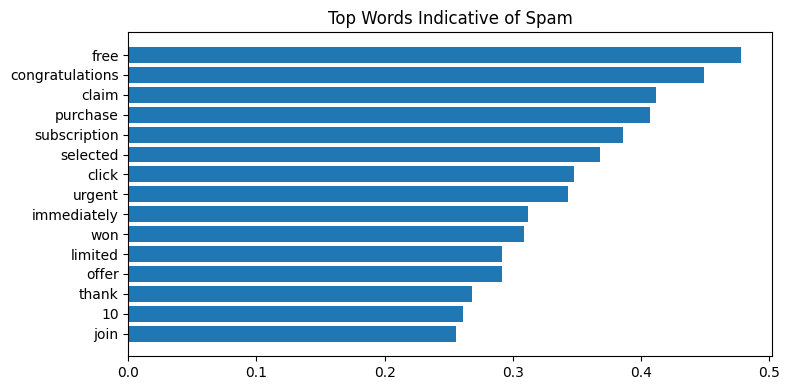

Top spam words: ['join', '10', 'thank', 'offer', 'limited', 'won', 'immediately', 'urgent', 'click', 'selected', 'subscription', 'purchase', 'claim', 'congratulations', 'free']


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Extract TF-IDF features and model coefficients
tfidf = pipeline.named_steps["tfidf"]
model = pipeline.named_steps["model"]

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

# Get top 15 spam-indicative words
top_spam_idx = np.argsort(coefficients)[-15:]
top_spam_words = feature_names[top_spam_idx]
top_spam_scores = coefficients[top_spam_idx]

# Plot top spam words
ensure_dir("reports/figures")
plt.figure(figsize=(8,4))
plt.barh(top_spam_words, top_spam_scores)
plt.title("Top Words Indicative of Spam")
plt.tight_layout()
plt.savefig("reports/figures/top_spam_words.png", dpi=150)
plt.show()

print("Top spam words:", list(top_spam_words))

In [26]:
# Function to predict new emails
def predict_spam(text):
    model = joblib.load("models/spam_pipeline.joblib")
    pred = model.predict([text])[0]
    return "Spam" if pred == 1 else "Not Spam"

# Example predictions
print(predict_spam("Win cash prizes now"))
print(predict_spam("Can we reschedule the meeting?"))
print(predict_spam("Limited time offer just for you"))
print(predict_spam("Lunch at 12 pm tomorrow?"))

Not Spam
Not Spam
Spam
Not Spam
